# 14 &middot; Bending Stiffness: a Mass-Spring Beam that Resists Bending

Tutorial 11 built a mass-spring **cable** &mdash; springs only resist *stretch*,
so pinned at both ends it sags into a catenary and pinned at one end it just
flops down. Here we add a **bending** energy so the beam resists *curvature*,
clamp it at one end (a cantilever), and watch it go from floppy to rigid as the
bending stiffness grows. Then we refine the mesh and watch the equilibrium
converge to a single shape.

| step | what we do |
|---|---|
| **1** | springs alone can't hold a shape (clamp one end, gravity on) |
| **2** | bending energy = penalize the hinge *turning angle* |
| **3** | sweep stiffness: the beam flops when soft, holds its shape when stiff |
| **4** | refine the mesh &rarr; the equilibrium converges to one curve |

In [1]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils

## The cantilever and its potential

A horizontal chain of `N` nodes: consecutive nodes are joined by **springs**
(stretch) and every interior node carries a **hinge** that measures the turning
angle between its two segments (bend). We **clamp the root** by pinning the two
leftmost nodes &mdash; fixing two nodes fixes both the position *and* the tangent
of the built-in end, which is what makes it a cantilever rather than a free
pivot.

With flattened positions $x$ the total potential is

$$
\Phi(x) = \underbrace{E_\text{stretch}(x)}_{\text{springs}}
   + \underbrace{E_\text{bend}(x)}_{\text{hinges}}
   - \underbrace{f_g^\top x}_{\text{gravity}}
   + \underbrace{\tfrac12 x^\top Q x + b^\top x}_{\text{clamp}} .
$$

The bending term is simkit's unified `bending_energy_x(x, C, theta0, kappa)`:
each hinge stores $\tfrac12\,\kappa\,(\theta-\theta_0)^2$ where $\theta$
is the signed turning angle (`dihedral_angles`) and $\theta_0=0$ for a straight
rest beam. We pick the physical constants so the discretization is
**mesh-independent** (so step 4's refinement converges): for a continuum beam of
length $L$, bending modulus $EI$, axial stiffness $EA$ and segment
length $l=L/(N-1)$,

* bending: $\kappa = EI/l$  (from $\tfrac12 EI\!\int\!\kappa^2\,ds$ with turning angle $\theta\approx \kappa\,l$),
* stretch: spring stiffness $EA/l$ (set `ym = EA`, quadrature weight `vol = l`), with $EA \gg EI$ so the beam is near-inextensible,
* mass/gravity: a lumped mass matrix that distributes the fixed total mass $\rho L$ regardless of `N`.

## A small, readable simulator

`BendingBeam` assembles the cantilever as a sum of named term helpers from
`utils` &mdash; a mass-spring **stretch** energy, a fixed **pin** clamp, and
**gravity** &mdash; plus an inline **bending** term that calls simkit's unified
`bending_*_x` on the hinge triples. `EI = 0` disables bending (springs only).
The static `energy / gradient / hessian` sum those terms **one per line**;
`step()` adds the backward-Euler `inertia` term and Newton-solves, exactly like
every other dynamic tutorial.

In [2]:
L, EA, RHO, G = 4.0, 2.0e4, 0.2, -9.8     # fixed continuum beam + load
PIN_PEN = 1e10


class Bending:
    """Inline bending term: 1/2 kappa (theta - theta0)^2 over the hinge triples,
    calling simkit's unified bending_*_x (theta = signed turning angle)."""
    def __init__(self, C, theta0, kappa):
        self.C, self.theta0, self.kappa = C, theta0, kappa

    def energy(self, x):   return energies.bending_energy_x(x, self.C, self.theta0, self.kappa)
    def gradient(self, x): return energies.bending_gradient_x(x, self.C, self.theta0, self.kappa)
    def hessian(self, x):  return energies.bending_hessian_x(x, self.C, self.theta0, self.kappa, psd=True)


class BendingBeam:
    """Cantilever potential = springs + bending + gravity + clamp.
    Static `solve()` minimizes it; `step()` adds inertia for dynamics."""

    def __init__(self, N=21, EI=50.0, h=0.02):
        self.X = np.zeros((N, 2)); self.X[:, 0] = np.linspace(0, L, N)
        self.E = np.array([[i, i + 1] for i in range(N - 1)])          # springs
        self.C = np.array([[i, i + 1, i + 2] for i in range(N - 2)])   # hinge triples
        self.n, self.dim = self.X.shape
        l_seg = L / (N - 1)

        # stretching (mass-springs, as in tutorial 11): stiffness EA/l <- ym=EA, vol=l
        Be = simkit.edge_displacement_jacobian(self.X, self.E)
        J = sp.sparse.kron(Be, sp.sparse.eye(self.dim)).tocsc()
        l0 = simkit.edge_lengths(self.X, self.E).reshape(-1, 1)
        ym = np.full((self.E.shape[0], 1), EA); vol = l0.copy()        # vol = l_seg
        self.spring = utils.SpringEnergy(J, ym, vol, l0)

        # bending (unified energy; kappa = EI/l, theta0 = 0 for a straight beam)
        theta0 = simkit.dihedral_angles(self.X, self.C)
        kappa = np.full((self.C.shape[0], 1), EI / l_seg)
        self.bending = Bending(self.C, theta0, kappa)

        # mass, gravity, clamp (pin the two leftmost nodes), inertia
        self.M = sp.sparse.kron(simkit.massmatrix(self.X, self.E, rho=RHO),
                                sp.sparse.eye(self.dim)).tocsc()
        f_g = simkit.gravity_force(self.X, self.E, a=G, rho=RHO).reshape(-1, 1)
        self.gravity = utils.Gravity(f_g)
        self.pin = utils.PenaltySpring(self.n, self.dim, PIN_PEN).set([0, 1], self.X[[0, 1]])
        self.inertia = utils.Inertia(self.M, h)
        self.h = h

    # ---- static potential Phi(x) ----
    def energy(self, x):
        E_spring  = self.spring.energy(x)
        E_bending = self.bending.energy(x)
        E_gravity = self.gravity.energy(x)
        E_pin     = self.pin.energy(x)
        return E_spring + E_bending + E_gravity + E_pin

    def gradient(self, x):
        g_spring  = self.spring.gradient(x)
        g_bending = self.bending.gradient(x)
        g_gravity = self.gravity.gradient(x)
        g_pin     = self.pin.gradient(x)
        return g_spring + g_bending + g_gravity + g_pin

    def hessian(self, x):
        H_spring  = self.spring.hessian(x)
        H_bending = self.bending.hessian(x)
        H_pin     = self.pin.hessian(x)
        return H_spring + H_bending + H_pin

    # ---- dynamic potential = static potential + backward-Euler inertia ----
    def dyn_energy(self, x):
        E_inertia = self.inertia.energy(x)
        return E_inertia + self.energy(x)

    def dyn_gradient(self, x):
        g_inertia = self.inertia.gradient(x)
        return g_inertia + self.gradient(x)

    def dyn_hessian(self, x):
        H_inertia = self.inertia.hessian(x)
        return H_inertia + self.hessian(x)

    def solve(self, iters=120):
        x = self.X.flatten().astype(float).reshape(-1, 1)
        x = newton_solver(x, self.energy, self.gradient, self.hessian,
                          max_iter=iters, do_line_search=True)
        return x.reshape(self.n, self.dim)

    def step(self, x_n, v_n, iters=20):
        self.inertia.update(x_n, v_n)
        return newton_solver(x_n.copy(), self.dyn_energy, self.dyn_gradient,
                             self.dyn_hessian, max_iter=iters, do_line_search=True)


def simulate(beam, n_steps=160, n_frames=60):
    """Backward-Euler release from the flat rest shape; sample n_frames states."""
    n, dim, M, h = beam.n, beam.dim, beam.M, beam.h
    x = beam.X.flatten().astype(float).reshape(-1, 1)
    v = np.zeros_like(x)
    states, ke, ts = [beam.X.copy()], [0.0], [0.0]
    sample = np.linspace(0, n_steps, n_frames).astype(int)
    for s in range(1, n_steps + 1):
        x_new = beam.step(x, v)
        v = (x_new - x) / h; x = x_new
        if s in sample:
            states.append(x.reshape(n, dim).copy())
            ke.append(0.5 * (v.T @ (M @ v))[0, 0]); ts.append(s * h)
    return states, np.array(ke), np.array(ts)


beam0 = BendingBeam(21, EI=50.0)
U0 = beam0.solve()
print("default cantilever: |grad| =", f"{np.linalg.norm(beam0.gradient(U0.flatten().reshape(-1,1))):.1e}",
      " tip =", np.round(U0[-1], 3))

default cantilever: |grad| = 2.9e-05  tip = [ 3.83  -1.064]


## 1 &middot; Springs alone can't hold a shape

Turn bending **off** (`EI = 0`) and release the clamped chain under gravity. With
no resistance to curvature the beam folds and flops straight down &mdash; exactly
the cable behavior from tutorial 11. The kinetic energy keeps sloshing because
there is nothing to settle the shape into.

In [3]:
states, ke, ts = simulate(BendingBeam(21, EI=0.0), n_steps=160, n_frames=60)
fig, anim = utils.animate_springs_energy(
    states, beam0.E, ts, {"kinetic": ke}, rest=beam0.X,
    lims=((-0.6, 4.6), (-4.3, 0.6)), xlabel="time (s)", ylabel="kinetic energy",
    scene_title="springs only (EI = 0): it flops down", title="kinetic energy",
    colors={"kinetic": utils.ENERGY_COLORS["kinetic"]}, pin_pts=beam0.X[[0, 1]])
utils.show_video(fig, anim, "media/14_springs_only.mp4", fps=20)

## 2 &middot; Bending energy penalizes the turning angle

At each interior node the **hinge angle** $\theta$ is the signed turn between
the incoming and outgoing segments (`simkit.dihedral_angles`); it is $0$ for a
straight beam. The bending energy sums $\tfrac12\,\kappa\,(\theta-\theta_0)^2$
over hinges, so it grows quadratically as we curl the beam into an arc of
increasing total turning angle $\Phi$.

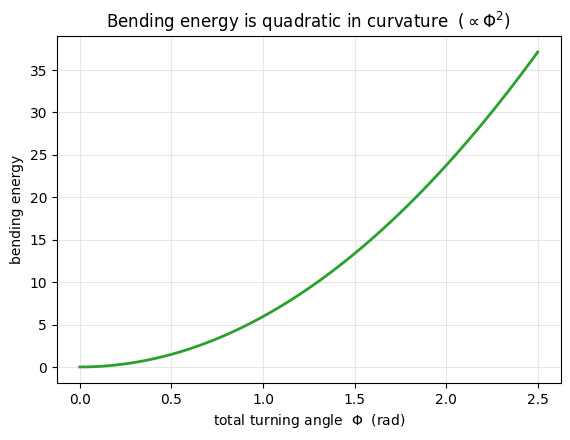

In [4]:
def arc_shape(N, total_turn, L=L):
    """Bend a straight beam into a circular arc with given total turning angle."""
    l = L / (N - 1)
    dphi = total_turn / (N - 1)                       # turn added at each segment
    angs = -0.5 * total_turn + dphi * np.arange(N - 1) + dphi / 2  # segment headings
    pts = np.zeros((N, 2))
    for i in range(N - 1):
        pts[i + 1] = pts[i] + l * np.array([np.cos(angs[i]), np.sin(angs[i])])
    return pts

N = 21
beamN = BendingBeam(N)
C, theta0 = beamN.C, simkit.dihedral_angles(beamN.X, beamN.C)
kappa = np.full((C.shape[0], 1), 50.0 / (L / (N - 1)))
turns = np.linspace(0.0, 2.5, 60)
Ebend = [energies.bending_energy_x(arc_shape(N, t).flatten().reshape(-1, 1), C, theta0, kappa) for t in turns]

fig, ax = utils.line_plot(turns, {"bending energy": Ebend},
    xlabel=r"total turning angle  $\Phi$  (rad)", ylabel="bending energy",
    colors={"bending energy": utils.ENERGY_COLORS["elastic"]},
    title=r"Bending energy is quadratic in curvature  ($\propto \Phi^2$)")
plt.show()

## 3 &middot; Flop when soft, hold its shape when stiff

Now release the cantilever under gravity at three bending stiffnesses. The soft
beam **flops around** and droops nearly straight down; as $EI$ grows the beam
**retains its shape**, barely deflecting from horizontal. (Stretching stays stiff
throughout &mdash; $EA \gg EI$ &mdash; so what changes is purely the
resistance to *bending*.)

In [5]:
panels = []
for EI, label in [(2.0, "soft  (EI=2)"), (50.0, "medium  (EI=50)"), (2000.0, "stiff  (EI=2000)")]:
    states, _, _ = simulate(BendingBeam(21, EI=EI), n_steps=160, n_frames=60)
    panels.append({"states": states, "E": beam0.E, "title": label})
fig, anim = utils.animate_springs_grid(
    panels, lims=((-0.6, 4.6), (-4.3, 0.6)), fps=20, pin_pts=beam0.X[[0, 1]],
    suptitle="Same beam, same gravity: stiffer bending = holds its shape")
utils.show_video(fig, anim, "media/14_flop_to_rigid.mp4", fps=20)

The **static equilibria** tell the same story: the droop shrinks steadily as
the bending stiffness increases.

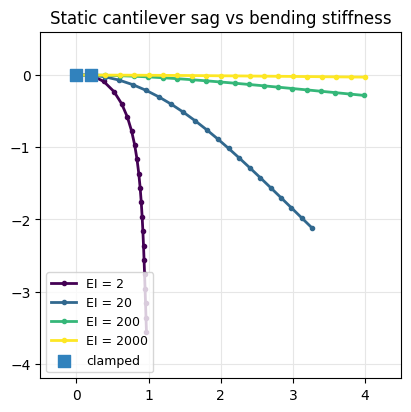

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
utils.setup_axes(ax, (-0.5, 4.5), (-4.2, 0.6), title="Static cantilever sag vs bending stiffness")
cmap = plt.get_cmap("viridis"); EIs = [2.0, 20.0, 200.0, 2000.0]
for j, EI in enumerate(EIs):
    Us = BendingBeam(21, EI=EI).solve()
    ax.plot(Us[:, 0], Us[:, 1], "-o", ms=3, lw=2, color=cmap(j / (len(EIs) - 1)), label=f"EI = {EI:g}")
ax.scatter(beam0.X[[0, 1], 0], beam0.X[[0, 1], 1], s=70, marker="s", color=utils.PIN_C, zorder=5, label="clamped")
ax.legend(fontsize=9, loc="lower left"); plt.show()

## 4 &middot; Refine the mesh &rarr; convergence to one shape

Hold the *continuum* beam fixed ($L, EI, EA, \rho, g$) and only change the
number of nodes `N`. Because the stiffnesses were scaled to be mesh-independent,
the discrete equilibria pile up onto a **single limiting curve**: coarse meshes
are too stiff and under-droop, but each refinement moves less than the last.

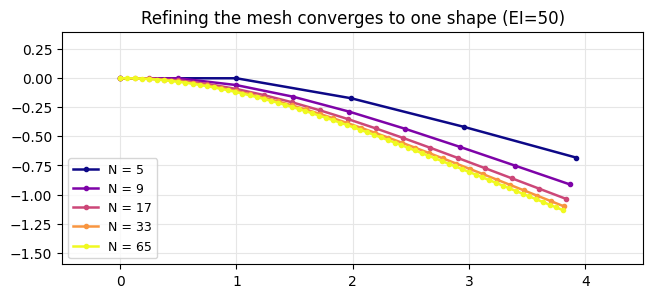

In [7]:
Ns = [5, 9, 17, 33, 65]
sols = {N: BendingBeam(N, EI=50.0).solve() for N in Ns}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
utils.setup_axes(ax, (-0.5, 4.5), (-1.6, 0.4), title="Refining the mesh converges to one shape (EI=50)")
cmap = plt.get_cmap("plasma")
for j, N in enumerate(Ns):
    U = sols[N]
    ax.plot(U[:, 0], U[:, 1], "-o", ms=3, lw=1.8, color=cmap(j / (len(Ns) - 1)), label=f"N = {N}")
ax.legend(fontsize=9, loc="lower left"); plt.show()

Measured against the finest mesh, the tip deflection error falls steadily with
resolution &mdash; first-order convergence (halving the segment size roughly
halves the error).

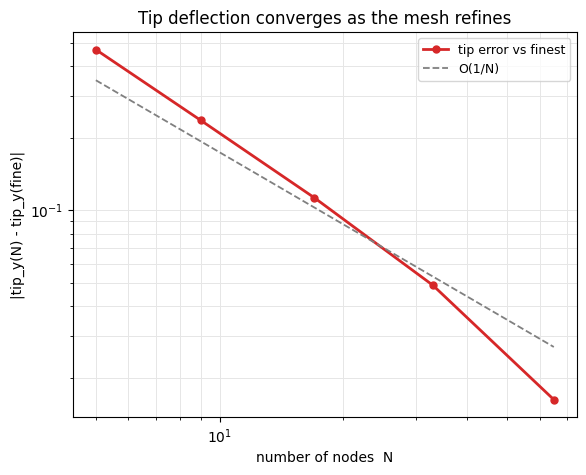

In [8]:
ref = BendingBeam(129, EI=50.0).solve()[-1, 1]
Nc = [5, 9, 17, 33, 65]
err = [abs(BendingBeam(N, EI=50.0).solve()[-1, 1] - ref) for N in Nc]
fig, ax = utils.loglog_plot(np.array(Nc), {"tip error vs finest": err},
    xlabel="number of nodes  N", ylabel="|tip_y(N) - tip_y(fine)|",
    colors={"tip error vs finest": "#d62728"}, ref_slopes={"O(1/N)": -1},
    title="Tip deflection converges as the mesh refines")
plt.show()

## 5 &middot; Aside: the same bending one dimension up

The hinge angle we used here is the **2D** member of one family. Discrete bending
always lives on a *codimension-1 hinge* shared by two flaps, and the energy
$\tfrac12\,\kappa\,(\theta-\theta_0)^2$ is identical across dimensions &mdash;
only the geometry of $\theta$ changes:

| | flaps | shared hinge | connectivity | angle |
|---|---|---|---|---|
| **curve in 2D** (this tutorial) | edges | a **vertex** | triple `(A,B,C)` | hinge turning angle |
| **surface in 3D** (cloth/shells) | triangles | an **edge** | quad `(x0,x1,x2,x3)` | dihedral fold angle |

simkit reflects this: `simkit.dihedral_angles(X, C)` returns the hinge angle for
`(n,2)` positions with triple connectivity and the dihedral angle for `(n,3)`
positions with quad connectivity &mdash; the dimension is inferred from the data.
The same `bending_energy_x(x, C, theta0, kappa)` assembles both; the 3D
`discrete_shells_bending_*` functions are thin wrappers over it. So everything
above carries over to a bending **cloth** by swapping the connectivity and adding
a third coordinate.

### Takeaways
* Springs resist stretch; a **bending** energy on the hinge angles is what lets a
  beam resist *curvature* and hold a shape.
* Increasing bending stiffness $EI$ takes the cantilever from **floppy** (flops
  down under gravity) to **rigid** (holds nearly horizontal).
* Scaling the discrete stiffnesses to a fixed continuum beam makes the simulation
  **mesh-independent**: refining `N` converges to a single equilibrium shape.
* The 2D hinge and 3D dihedral bending are the *same* energy one codimension
  apart &mdash; unified behind `simkit.dihedral_angles` / `bending_energy_x`.